In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
!pip install -q shap lime fairlearn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 5.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.5/135.5 kB 11.1 MB/s eta 0:00:00


In [67]:
import shap
import lime
import fairlearn
from importlib.metadata import version

print("SHAP:", shap.__version__)
print("LIME:", version("lime"))
print("Fairlearn:", version("fairlearn"))

SHAP: 0.52.0
LIME: 0.2.0.1
Fairlearn: 0.14.0


In [68]:
import pandas as pd
import joblib

DATA_PATH = "/content/drive/MyDrive/ADSProject/Project_Root/Final_Cleaned_Dataset/master_df.csv"

master_df = pd.read_csv(DATA_PATH)

print("Dataset shape:", master_df.shape)

Dataset shape: (7043, 47)


In [69]:
MODEL_PATH = "/content/drive/MyDrive/ADSProject/Project_Root/Models/best_churn_model.pkl"

final_model = joblib.load(MODEL_PATH)

print("Model loaded successfully!")

Model loaded successfully!


In [70]:
target = "Churn Label"

leakage_columns = [
    "Churn Value",
    "Churn Reason",
    "Customer Status",
    "Churn Score"
]

leakage_columns = [
    col for col in leakage_columns
    if col in master_df.columns
]

X = master_df.drop(
    columns=[target] + leakage_columns
)

y = master_df[target].map({
    "Yes": 1,
    "No": 0
})

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (7043, 42)
y shape: (7043,)


In [71]:
print("Final model:", type(final_model))

Final model: <class 'sklearn.pipeline.Pipeline'>


SHAP

In [72]:
X_background = X.sample(30, random_state=42)
X_shap = X.sample(50, random_state=42)

print("Background data:", X_background.shape)
print("SHAP data:", X_shap.shape)

Background data: (30, 42)
SHAP data: (50, 42)


In [73]:
def predict_proba_for_shap(data):
    data_df = pd.DataFrame(data, columns=X.columns)
    return final_model.predict_proba(data_df)

In [74]:
test_prediction = predict_proba_for_shap(X_background)

print("Prediction shape:", test_prediction.shape)
print(test_prediction[:5])

Prediction shape: (30, 2)
[[6.7436337e-02 9.3256366e-01]
 [9.9961573e-01 3.8428258e-04]
 [9.9991906e-01 8.0920938e-05]
 [9.1183186e-04 9.9908817e-01]
 [2.2727251e-04 9.9977273e-01]]


In [75]:
import shap
import numpy as np
import matplotlib.pyplot as plt

explainer = shap.KernelExplainer(
    predict_proba_for_shap,
    X_background
)

print("SHAP explainer created successfully!")

SHAP explainer created successfully!


In [76]:
shap_values = explainer.shap_values(X_shap)

  0%|          | 0/50 [00:00<?, ?it/s]

In [77]:
print("SHAP calculation completed!")
print("Type:", type(shap_values))
print("Shape:", np.array(shap_values).shape)

SHAP calculation completed!
Type: <class 'numpy.ndarray'>
Shape: (50, 42, 2)


In [78]:
print("SHAP type:", type(shap_values))

if isinstance(shap_values, list):
    print("Number of outputs:", len(shap_values))
    for i, value in enumerate(shap_values):
        print(f"Output {i} shape:", np.array(value).shape)
else:
    print("SHAP array shape:", np.array(shap_values).shape)

SHAP type: <class 'numpy.ndarray'>
SHAP array shape: (50, 42, 2)


In [79]:
if isinstance(shap_values, list):
    shap_class_1 = shap_values[1]
else:
    shap_array = np.array(shap_values)

    if shap_array.ndim == 3:
        shap_class_1 = shap_array[:, :, 1]
    else:
        shap_class_1 = shap_array

print("Class 1 SHAP shape:", np.array(shap_class_1).shape)

Class 1 SHAP shape: (50, 42)


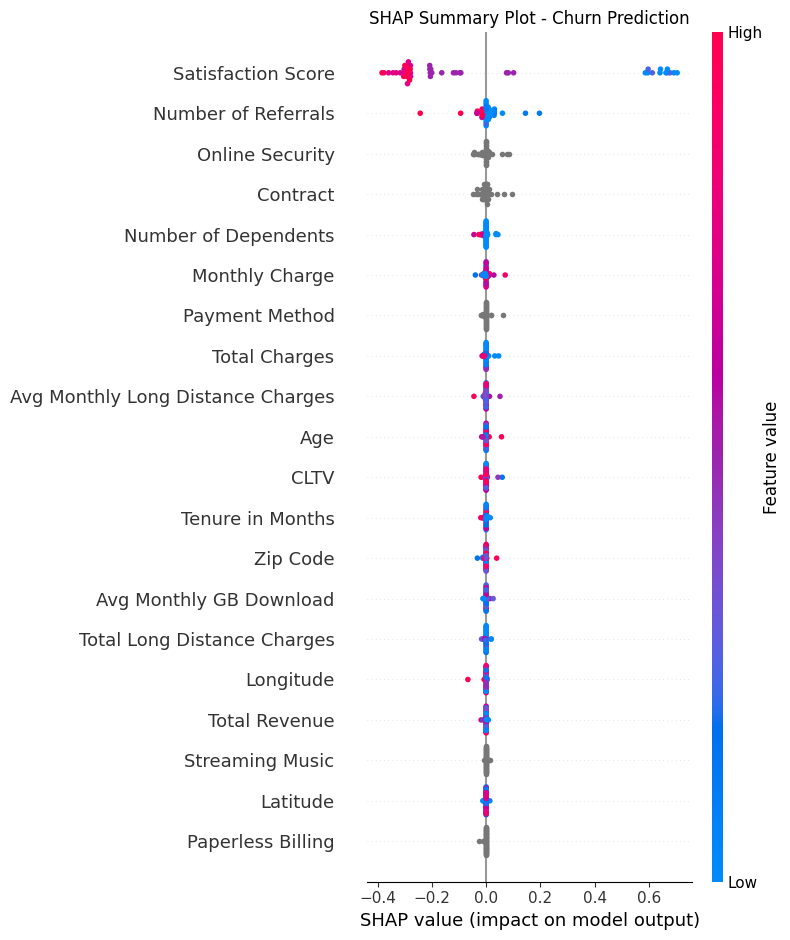

In [80]:
plt.figure(figsize=(10, 7))

shap.summary_plot(
    shap_class_1,
    X_shap,
    show=False
)

plt.title("SHAP Summary Plot - Churn Prediction")
plt.tight_layout()
plt.show()

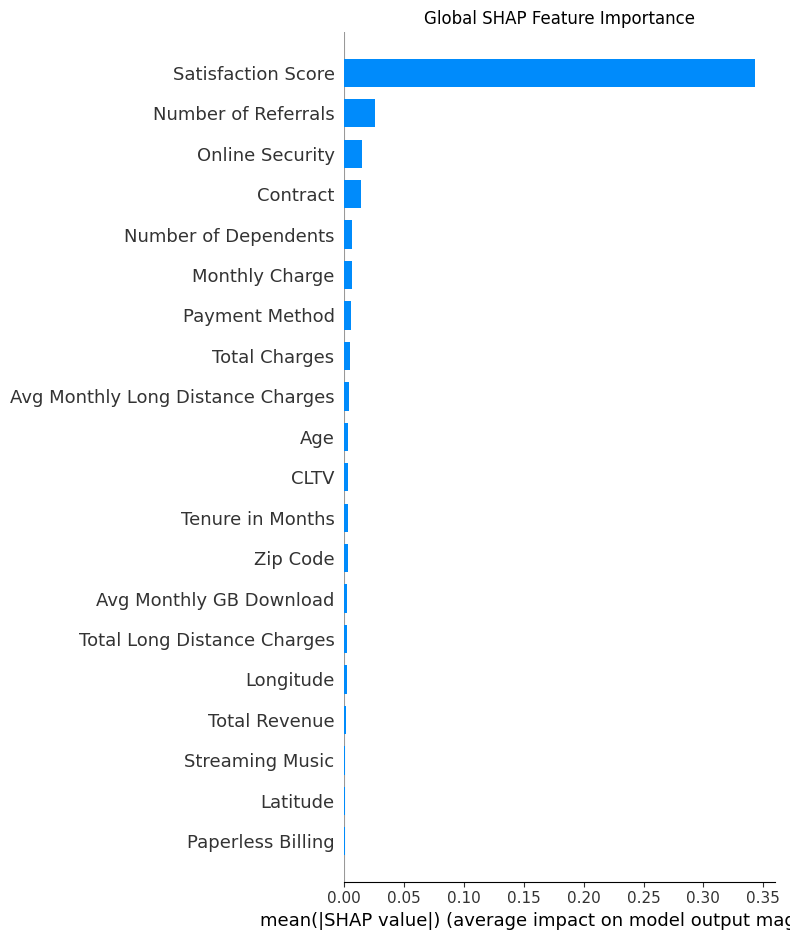

In [81]:
plt.figure(figsize=(10, 7))

shap.summary_plot(
    shap_class_1,
    X_shap,
    plot_type="bar",
    show=False
)

plt.title("Global SHAP Feature Importance")
plt.tight_layout()
plt.show()

In [82]:
mean_abs_shap = np.abs(shap_class_1).mean(axis=0)

feature_importance = pd.DataFrame({
    "Feature": X_shap.columns,
    "Mean Absolute SHAP": mean_abs_shap
}).sort_values(
    "Mean Absolute SHAP",
    ascending=False
)

print(feature_importance.head(10))

                              Feature  Mean Absolute SHAP
34                 Satisfaction Score            0.343041
8                 Number of Referrals            0.025694
17                    Online Security            0.014346
25                           Contract            0.014064
6                Number of Dependents            0.006496
28                     Monthly Charge            0.006361
27                     Payment Method            0.005528
29                      Total Charges            0.004398
12  Avg Monthly Long Distance Charges            0.003623
1                                 Age            0.003417


In [83]:
top_feature = feature_importance.iloc[0]["Feature"]

print("Top SHAP feature:", top_feature)

Top SHAP feature: Satisfaction Score


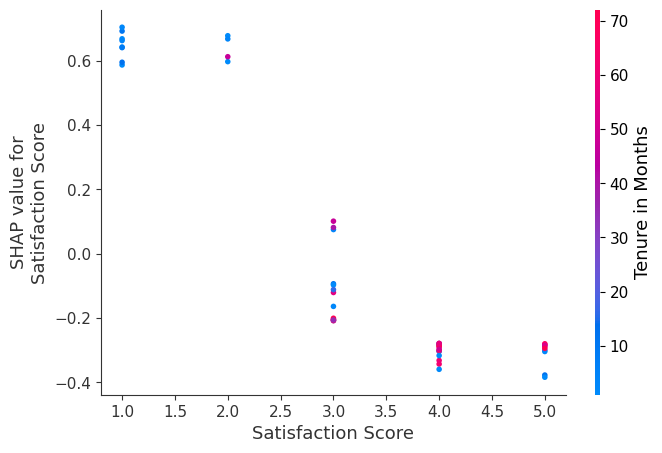

In [84]:
shap.dependence_plot(
    top_feature,
    shap_class_1,
    X_shap,
    show=True
)

In [85]:
shap_class_1 = shap_values[:, :, 1]

print("Churn SHAP shape:", shap_class_1.shape)

Churn SHAP shape: (50, 42)


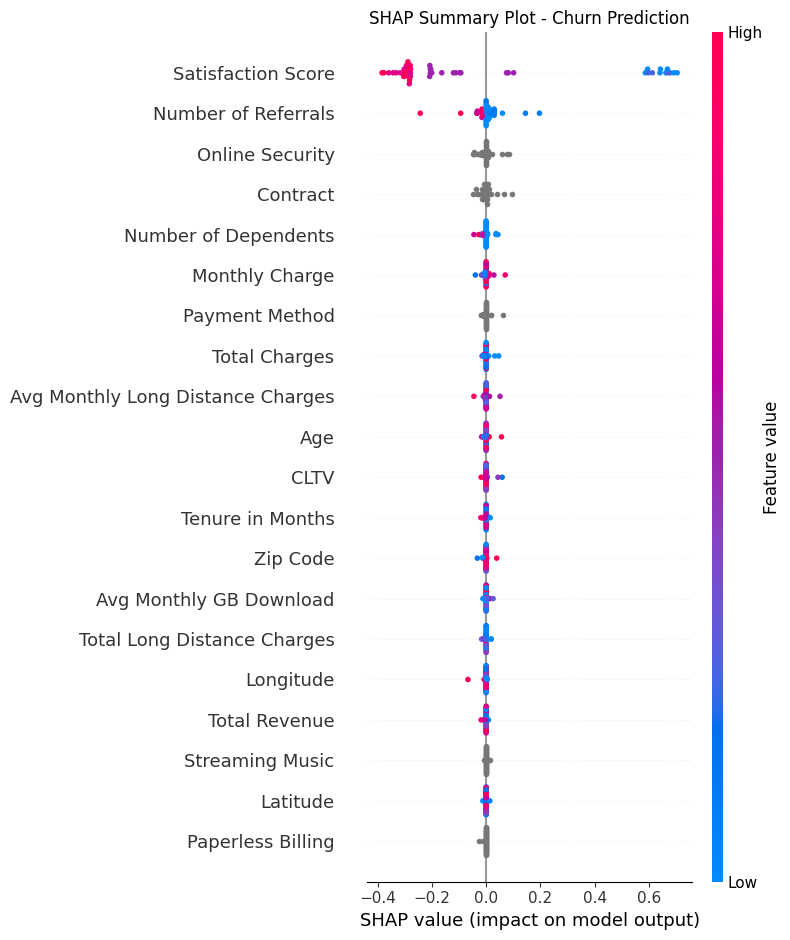

In [86]:
plt.figure(figsize=(10, 7))

shap.summary_plot(
    shap_class_1,
    X_shap,
    show=False
)

plt.title("SHAP Summary Plot - Churn Prediction")
plt.tight_layout()
plt.show()

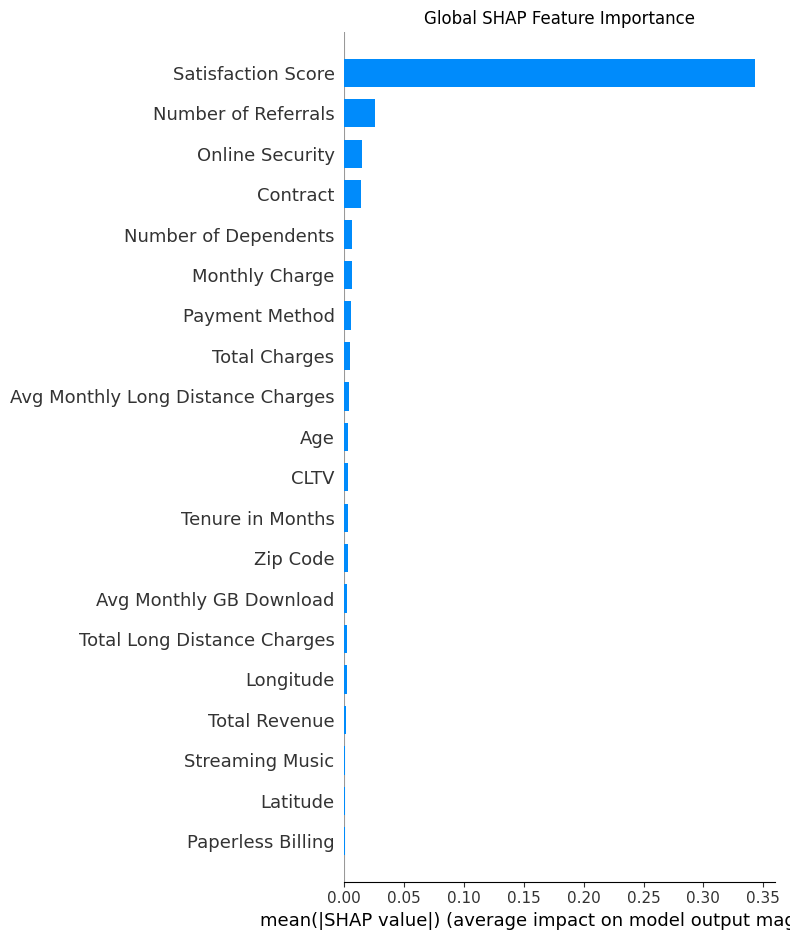

In [87]:
plt.figure(figsize=(10, 7))

shap.summary_plot(
    shap_class_1,
    X_shap,
    plot_type="bar",
    show=False
)

plt.title("Global SHAP Feature Importance")
plt.tight_layout()
plt.show()

In [88]:
mean_abs_shap = np.abs(shap_class_1).mean(axis=0)

feature_importance = pd.DataFrame({
    "Feature": X_shap.columns,
    "Mean Absolute SHAP": mean_abs_shap
}).sort_values(
    "Mean Absolute SHAP",
    ascending=False
)

print(feature_importance.head(10))

                              Feature  Mean Absolute SHAP
34                 Satisfaction Score            0.343041
8                 Number of Referrals            0.025694
17                    Online Security            0.014346
25                           Contract            0.014064
6                Number of Dependents            0.006496
28                     Monthly Charge            0.006361
27                     Payment Method            0.005528
29                      Total Charges            0.004398
12  Avg Monthly Long Distance Charges            0.003623
1                                 Age            0.003417


In [89]:
top_feature = feature_importance.iloc[0]["Feature"]

print("Top SHAP feature:", top_feature)

Top SHAP feature: Satisfaction Score


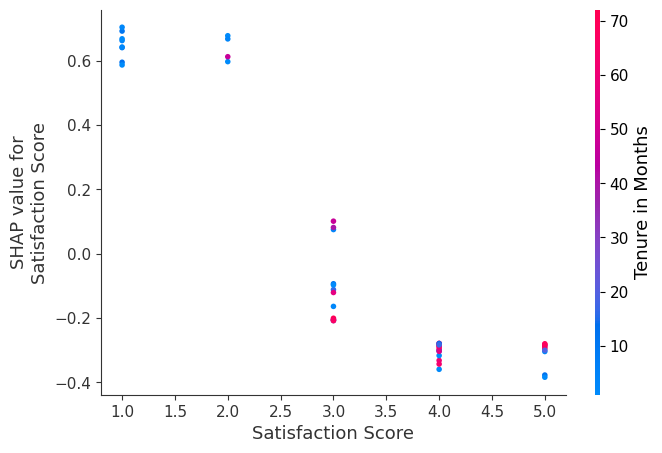

In [90]:
shap.dependence_plot(
    top_feature,
    shap_class_1,
    X_shap
)

In [91]:
print(feature_importance.head(10))

                              Feature  Mean Absolute SHAP
34                 Satisfaction Score            0.343041
8                 Number of Referrals            0.025694
17                    Online Security            0.014346
25                           Contract            0.014064
6                Number of Dependents            0.006496
28                     Monthly Charge            0.006361
27                     Payment Method            0.005528
29                      Total Charges            0.004398
12  Avg Monthly Long Distance Charges            0.003623
1                                 Age            0.003417


In [92]:
import os

SHAP_DIR = "/content/drive/MyDrive/ADSProject/Project_Root/XAI_Results/SHAP"
os.makedirs(SHAP_DIR, exist_ok=True)

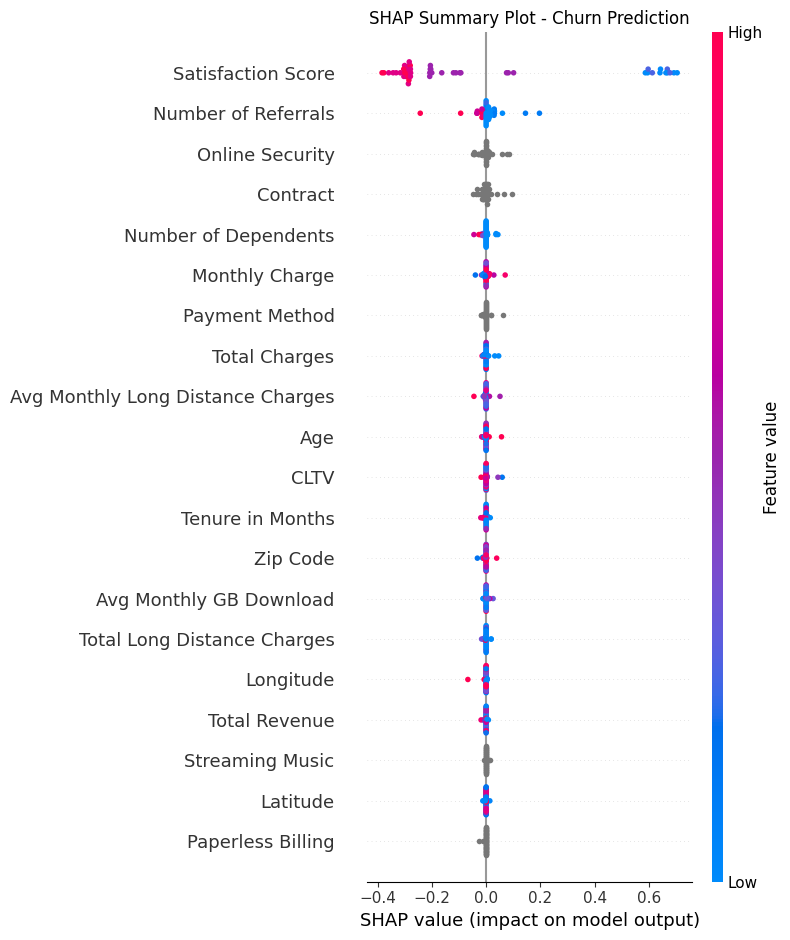

In [93]:
plt.figure(figsize=(10, 7))

shap.summary_plot(
    shap_class_1,
    X_shap,
    show=False
)

plt.title("SHAP Summary Plot - Churn Prediction")
plt.tight_layout()

plt.savefig(
    f"{SHAP_DIR}/shap_summary.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

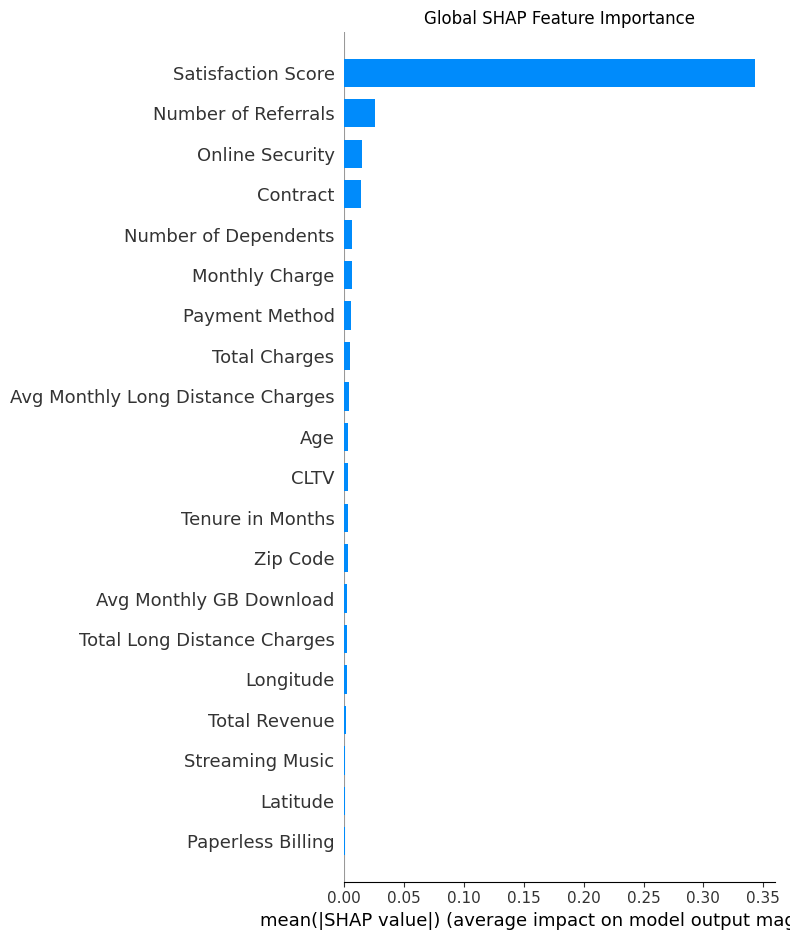

In [94]:
plt.figure(figsize=(10, 7))

shap.summary_plot(
    shap_class_1,
    X_shap,
    plot_type="bar",
    show=False
)

plt.title("Global SHAP Feature Importance")
plt.tight_layout()

plt.savefig(
    f"{SHAP_DIR}/shap_feature_importance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

<Figure size 1000x700 with 0 Axes>

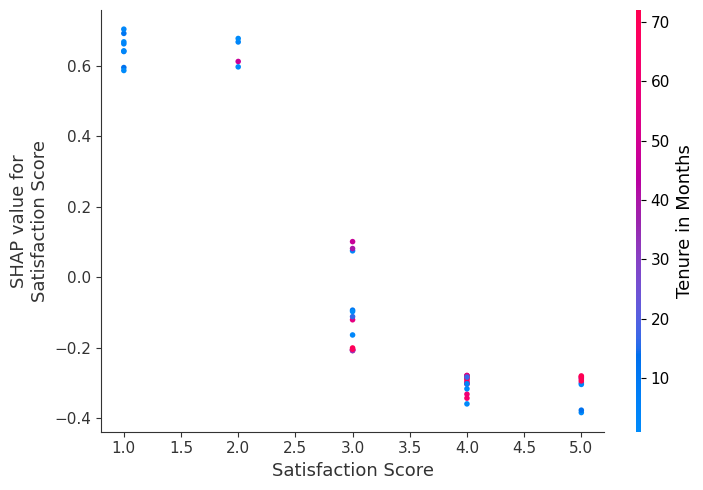

In [95]:
plt.figure(figsize=(10, 7))

shap.dependence_plot(
    top_feature,
    shap_class_1,
    X_shap,
    show=False
)

plt.tight_layout()

plt.savefig(
    f"{SHAP_DIR}/shap_dependence.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

LIME

In [117]:
from lime.lime_tabular import LimeTabularExplainer
import numpy as np
import pandas as pd

categorical_features = X.select_dtypes(
    include=["object", "bool", "category"]
).columns.tolist()

numeric_features = X.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

print("Numeric features:", len(numeric_features))
print("Categorical features:", len(categorical_features))

categorical_feature_indices = [
    X.columns.get_loc(col)
    for col in categorical_features
]

print("Categorical feature indices:")
print(categorical_feature_indices)

categorical_names = {}

for index in categorical_feature_indices:
    categorical_names[index] = (
        X.iloc[:, index]
        .astype(str)
        .unique()
        .tolist()
    )

print("Categorical mappings created.")

X_lime = X.copy()

for col in categorical_features:
    X_lime[col] = pd.Categorical(X_lime[col]).codes

print(X_lime.head())

print(X_lime.dtypes.value_counts())

Numeric features: 18
Categorical features: 24
Categorical feature indices:
[0, 2, 3, 4, 5, 7, 10, 11, 13, 14, 15, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 36, 38]
Categorical mappings created.
   Gender  Age  Under 30  Senior Citizen  Married  Dependents  \
0       1   78         0               1        0           0   
1       0   74         0               1        1           1   
2       1   71         0               1        0           1   
3       0   78         0               1        1           1   
4       0   80         0               1        1           1   

   Number of Dependents  Referred a Friend  Number of Referrals  \
0                     0                  0                    0   
1                     1                  1                    1   
2                     3                  0                    0   
3                     1                  1                    1   
4                     1                  1                    1   

   Tenure 

In [118]:
from lime.lime_tabular import LimeTabularExplainer

lime_explainer = LimeTabularExplainer(
    training_data=X_lime.values,
    feature_names=X.columns.tolist(),
    categorical_features=categorical_feature_indices,
    categorical_names=categorical_names,
    class_names=["No Churn", "Churn"],
    mode="classification",
    random_state=42
)

print("LIME explainer created successfully!")

LIME explainer created successfully!


In [119]:
def predict_proba_for_lime(data):

    data_df = pd.DataFrame(
        data,
        columns=X.columns
    )

    # Convert categorical encoded values back to original categories
    for col in categorical_features:

        col_index = X.columns.get_loc(col)

        categories = (
            X[col]
            .astype(str)
            .unique()
            .tolist()
        )

        data_df[col] = (
            data_df[col]
            .round()
            .clip(0, len(categories) - 1)
            .astype(int)
            .map(dict(enumerate(categories)))
        )

    return final_model.predict_proba(data_df)

In [120]:
customer_index = 0

customer = X_lime.iloc[customer_index].values

print("Customer selected:", customer_index)

lime_explanation = lime_explainer.explain_instance(
    customer,
    predict_proba_for_lime,
    num_features=10
)

print("LIME explanation generated successfully!")

lime_explanation.show_in_notebook(show_table=True)

lime_results = lime_explanation.as_list()

for feature, contribution in lime_results:
    print(f"{feature}: {contribution:.4f}")

Customer selected: 0
LIME explanation generated successfully!


Satisfaction Score <= 3.00: 0.9957
Lat Long=33.998471, -117.973758: -0.0092
Number of Dependents <= 0.00: 0.0016
Number of Referrals <= 0.00: 0.0006
Multiple Lines=No: -0.0005
Contract=Month-to-Month: 0.0005
Total Long Distance Charges <= 70.55: 0.0004
Premium Tech Support=No: 0.0004
Streaming Music=No: -0.0004
35.50 < Monthly Charge <= 70.35: -0.0003


In [121]:
import os

LIME_DIR = "/content/drive/MyDrive/ADSProject/Project_Root/XAI_Results/LIME"

os.makedirs(LIME_DIR, exist_ok=True)

print("LIME output directory ready:")
print(LIME_DIR)

LIME output directory ready:
/content/drive/MyDrive/ADSProject/Project_Root/XAI_Results/LIME


In [122]:
lime_explanation.save_to_file(
    f"{LIME_DIR}/lime_customer_0.html"
)

print("Interactive LIME visualization saved successfully!")
print(f"{LIME_DIR}/lime_customer_0.html")

Interactive LIME visualization saved successfully!
/content/drive/MyDrive/ADSProject/Project_Root/XAI_Results/LIME/lime_customer_0.html


In [123]:
lime_df = pd.DataFrame(
    lime_results,
    columns=["Feature", "Contribution"]
)

lime_df["Direction"] = lime_df["Contribution"].apply(
    lambda x: "Increases Churn" if x > 0 else "Decreases Churn"
)

lime_df.to_csv(
    f"{LIME_DIR}/lime_customer_0_results.csv",
    index=False
)

print("LIME feature contributions saved successfully!")
print(lime_df)

LIME feature contributions saved successfully!
                                Feature  Contribution        Direction
0            Satisfaction Score <= 3.00      0.995709  Increases Churn
1       Lat Long=33.998471, -117.973758     -0.009217  Decreases Churn
2          Number of Dependents <= 0.00      0.001605  Increases Churn
3           Number of Referrals <= 0.00      0.000650  Increases Churn
4                     Multiple Lines=No     -0.000514  Decreases Churn
5               Contract=Month-to-Month      0.000499  Increases Churn
6  Total Long Distance Charges <= 70.55      0.000383  Increases Churn
7               Premium Tech Support=No      0.000362  Increases Churn
8                    Streaming Music=No     -0.000358  Decreases Churn
9       35.50 < Monthly Charge <= 70.35     -0.000319  Decreases Churn


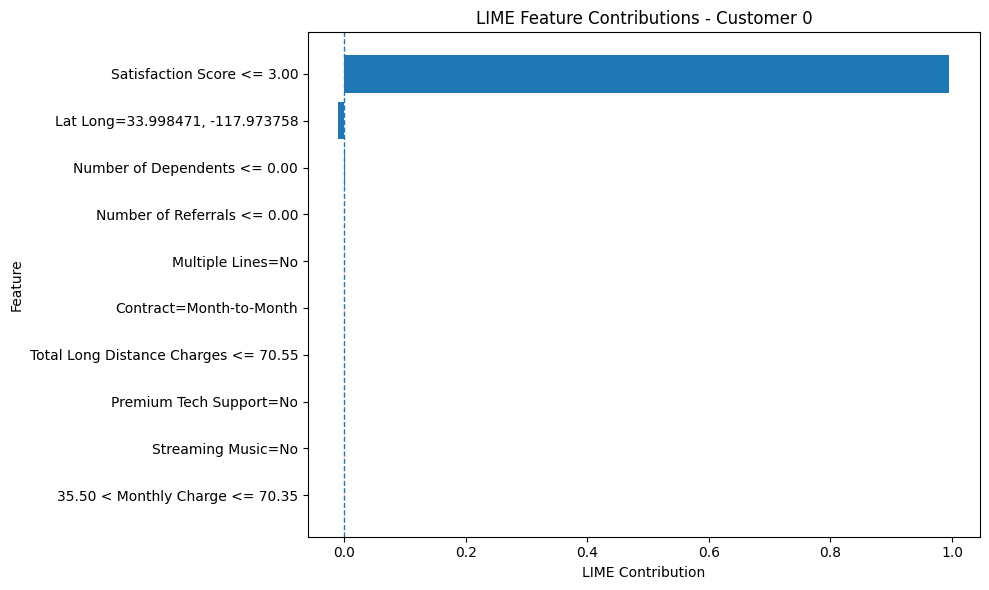

LIME visualization saved successfully!
/content/drive/MyDrive/ADSProject/Project_Root/XAI_Results/LIME/lime_customer_0_contributions.png


In [124]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

features = [x[0] for x in lime_results]
contributions = [x[1] for x in lime_results]

plt.barh(
    features[::-1],
    contributions[::-1]
)

plt.axvline(
    x=0,
    linestyle="--",
    linewidth=1
)

plt.xlabel("LIME Contribution")
plt.ylabel("Feature")
plt.title("LIME Feature Contributions - Customer 0")

plt.tight_layout()

lime_plot_path = f"{LIME_DIR}/lime_customer_0_contributions.png"

plt.savefig(
    lime_plot_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("LIME visualization saved successfully!")
print(lime_plot_path)

In [125]:
predicted_class = final_model.predict(
    X.iloc[[customer_index]]
)[0]

predicted_probability = final_model.predict_proba(
    X.iloc[[customer_index]]
)[0]

if predicted_class == 1:
    predicted_label = "Churn"
else:
    predicted_label = "No Churn"

report_path = f"{LIME_DIR}/lime_summary_customer_0.txt"

with open(report_path, "w") as f:

    f.write("=" * 60 + "\n")
    f.write("LIME EXPLAINABILITY SUMMARY REPORT\n")
    f.write("=" * 60 + "\n\n")

    f.write(f"Customer Index: {customer_index}\n")
    f.write(f"Predicted Class: {predicted_label}\n")
    f.write(f"No Churn Probability: {predicted_probability[0]:.4f}\n")
    f.write(f"Churn Probability: {predicted_probability[1]:.4f}\n\n")

    f.write("-" * 60 + "\n")
    f.write("TOP LIME FEATURE CONTRIBUTIONS\n")
    f.write("-" * 60 + "\n\n")

    for feature, contribution in lime_results:

        direction = (
            "Increases Churn"
            if contribution > 0
            else "Decreases Churn"
        )

        f.write(
            f"{feature}: "
            f"{contribution:.4f} "
            f"({direction})\n"
        )

    f.write("\n")
    f.write("=" * 60 + "\n")
    f.write("END OF REPORT\n")
    f.write("=" * 60 + "\n")

print("LIME summary report saved successfully!")
print(report_path)

LIME summary report saved successfully!
/content/drive/MyDrive/ADSProject/Project_Root/XAI_Results/LIME/lime_summary_customer_0.txt


Fairness Audit

In [106]:
# ============================================================
# CELL 1 — LOAD DATA AND FINAL MODEL
# ============================================================

import os
import joblib
import pandas as pd
import numpy as np

# ------------------------------------------------------------
# Paths
# ------------------------------------------------------------

DATA_PATH = (
    "/content/drive/MyDrive/ADSProject/"
    "Project_Root/Final_Cleaned_Dataset/master_df.csv"
)

MODEL_PATH = (
    "/content/drive/MyDrive/ADSProject/"
    "Project_Root/Models/best_churn_model.pkl"
)

# ------------------------------------------------------------
# Load cleaned dataset
# ------------------------------------------------------------

master_df = pd.read_csv(DATA_PATH)

print("Dataset loaded successfully!")
print("Dataset shape:", master_df.shape)

# ------------------------------------------------------------
# Load trained model
# ------------------------------------------------------------

final_model = joblib.load(MODEL_PATH)

print("Final model loaded successfully!")
print("Model type:", type(final_model))

Dataset loaded successfully!
Dataset shape: (7043, 47)
Final model loaded successfully!
Model type: <class 'sklearn.pipeline.Pipeline'>


In [107]:
# ============================================================
# CELL 2 — DEFINE FEATURES AND TARGET
# ============================================================

target = "Churn Label"

# Columns that would leak the target information
leakage_columns = [
    "Churn Value",
    "Churn Reason",
    "Customer Status",
    "Churn Score"
]

# Keep only columns that actually exist
leakage_columns = [
    col for col in leakage_columns
    if col in master_df.columns
]

# ------------------------------------------------------------
# Create X and y
# ------------------------------------------------------------

X = master_df.drop(
    columns=[target] + leakage_columns
)

y = master_df[target].map({
    "Yes": 1,
    "No": 0
})

print("Features shape:", X.shape)
print("Target shape:", y.shape)

print("\nTarget distribution:")
print(y.value_counts())

print("\nGender distribution:")
print(X["Gender"].value_counts(dropna=False))

Features shape: (7043, 42)
Target shape: (7043,)

Target distribution:
Churn Label
0    5174
1    1869
Name: count, dtype: int64

Gender distribution:
Gender
Male      3555
Female    3488
Name: count, dtype: int64


In [108]:
# ============================================================
# CELL 3 — TRAIN / TEST SPLIT
# ============================================================

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data :", X_test.shape)

print("\nTraining target distribution:")
print(y_train.value_counts())

print("\nTesting target distribution:")
print(y_test.value_counts())

print("\nGender distribution in test set:")
print(X_test["Gender"].value_counts(dropna=False))

Training data: (5634, 42)
Testing data : (1409, 42)

Training target distribution:
Churn Label
0    4139
1    1495
Name: count, dtype: int64

Testing target distribution:
Churn Label
0    1035
1     374
Name: count, dtype: int64

Gender distribution in test set:
Gender
Female    720
Male      689
Name: count, dtype: int64


In [109]:
# ============================================================
# CELL 4 — GENERATE MODEL PREDICTIONS
# ============================================================

y_pred = final_model.predict(X_test)

print("Predictions generated:", len(y_pred))

print("\nPrediction distribution:")
print(pd.Series(y_pred).value_counts())

# Sensitive attribute for fairness analysis
sensitive_feature = X_test["Gender"]

print("\nGender groups:")
print(sensitive_feature.value_counts())

Predictions generated: 1409

Prediction distribution:
0    1063
1     346
Name: count, dtype: int64

Gender groups:
Gender
Female    720
Male      689
Name: count, dtype: int64


In [110]:
# ============================================================
# CELL 5 — FAIRNESS METRICS
# ============================================================

from fairlearn.metrics import (
    demographic_parity_difference,
    equalized_odds_difference
)

# ------------------------------------------------------------
# Demographic Parity Difference
# ------------------------------------------------------------

dp_difference = demographic_parity_difference(
    y_test,
    y_pred,
    sensitive_features=sensitive_feature
)

# ------------------------------------------------------------
# Equalized Odds Difference
# ------------------------------------------------------------

eo_difference = equalized_odds_difference(
    y_test,
    y_pred,
    sensitive_features=sensitive_feature
)

print("========== FAIRNESS METRICS ==========")
print(f"Demographic Parity Difference: {dp_difference:.4f}")
print(f"Equalized Odds Difference: {eo_difference:.4f}")

========== FAIRNESS METRICS ==========
Demographic Parity Difference: 0.0403
Equalized Odds Difference: 0.0332


In [111]:
# ============================================================
# CELL 6 — GROUP-WISE PERFORMANCE
# ============================================================

from fairlearn.metrics import MetricFrame
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

metric_frame = MetricFrame(
    metrics={
        "Accuracy": accuracy_score,
        "Precision": precision_score,
        "Recall": recall_score,
        "F1": f1_score
    },
    y_true=y_test,
    y_pred=y_pred,
    sensitive_features=sensitive_feature
)

print("========== GROUP-WISE METRICS ==========")
print(metric_frame.by_group)

group_metrics = metric_frame.by_group.reset_index()

print("\nGroup metrics:")
print(group_metrics)

========== GROUP-WISE METRICS ==========
        Accuracy  Precision    Recall        F1
Gender                                         
Female  0.969444   0.973822  0.916256  0.944162
Male    0.965167   0.974194  0.883041  0.926380

Group metrics:
   Gender  Accuracy  Precision    Recall        F1
0  Female  0.969444   0.973822  0.916256  0.944162
1    Male  0.965167   0.974194  0.883041  0.926380


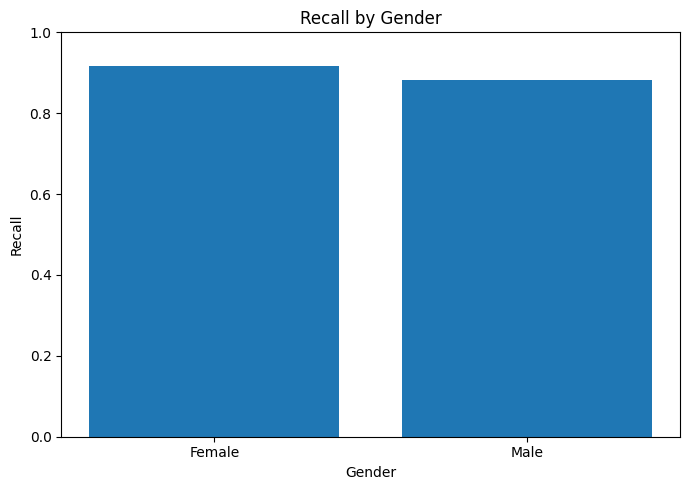

Recall visualization saved!


In [112]:
# ============================================================
# CELL 7 — RECALL BY GENDER
# ============================================================

import matplotlib.pyplot as plt

plt.figure(figsize=(7, 5))

plt.bar(
    group_metrics["Gender"].astype(str),
    group_metrics["Recall"]
)

plt.xlabel("Gender")
plt.ylabel("Recall")
plt.title("Recall by Gender")
plt.ylim(0, 1)

plt.tight_layout()

plt.savefig(
    f"{FAIRNESS_DIR}/recall_by_gender.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Recall visualization saved!")

<Figure size 800x500 with 0 Axes>

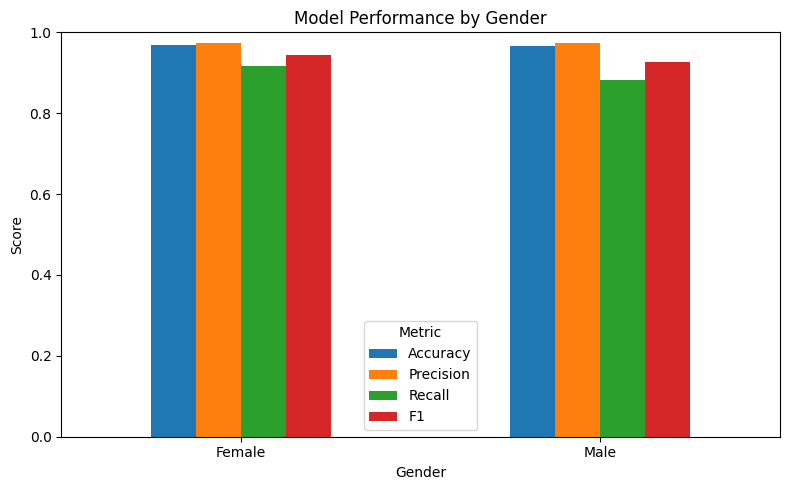

Performance comparison visualization saved!


In [113]:
# ============================================================
# CELL 8 — MODEL PERFORMANCE BY GENDER
# ============================================================

plt.figure(figsize=(8, 5))

metric_frame.by_group[
    ["Accuracy", "Precision", "Recall", "F1"]
].plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Model Performance by Gender")
plt.xlabel("Gender")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(title="Metric")

plt.tight_layout()

plt.savefig(
    f"{FAIRNESS_DIR}/performance_by_gender.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Performance comparison visualization saved!")

Predicted churn rate by gender:
   Gender  Prediction  Prediction Rate (%)
0  Female    0.265278            26.527778
1    Male    0.224964            22.496372


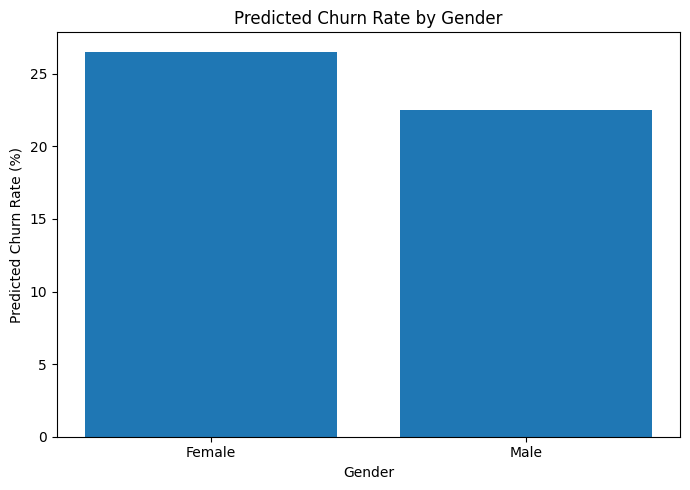

Predicted churn rate visualization saved!


In [114]:
# ============================================================
# CELL 9 — CHURN PREDICTION RATE BY GENDER
# ============================================================

prediction_rate = (
    pd.DataFrame({
        "Gender": sensitive_feature.values,
        "Prediction": y_pred
    })
    .groupby("Gender")["Prediction"]
    .mean()
    .reset_index()
)

prediction_rate["Prediction Rate (%)"] = (
    prediction_rate["Prediction"] * 100
)

print("Predicted churn rate by gender:")
print(prediction_rate)

plt.figure(figsize=(7, 5))

plt.bar(
    prediction_rate["Gender"].astype(str),
    prediction_rate["Prediction Rate (%)"]
)

plt.xlabel("Gender")
plt.ylabel("Predicted Churn Rate (%)")
plt.title("Predicted Churn Rate by Gender")

plt.tight_layout()

plt.savefig(
    f"{FAIRNESS_DIR}/predicted_churn_rate_by_gender.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Predicted churn rate visualization saved!")

In [115]:
# ============================================================
# CELL 10 — SAVE FAIRNESS RESULTS
# ============================================================

FAIRNESS_DIR = (
    "/content/drive/MyDrive/ADSProject/"
    "Project_Root/XAI_Results/Fairness"
)

os.makedirs(FAIRNESS_DIR, exist_ok=True)

# ------------------------------------------------------------
# Save group-wise metrics
# ------------------------------------------------------------

group_metrics.to_csv(
    f"{FAIRNESS_DIR}/fairness_group_metrics.csv",
    index=False
)

# ------------------------------------------------------------
# Save fairness summary
# ------------------------------------------------------------

fairness_summary = pd.DataFrame({
    "Metric": [
        "Demographic Parity Difference",
        "Equalized Odds Difference"
    ],
    "Value": [
        dp_difference,
        eo_difference
    ]
})

fairness_summary.to_csv(
    f"{FAIRNESS_DIR}/fairness_summary.csv",
    index=False
)

# ------------------------------------------------------------
# Save prediction rates
# ------------------------------------------------------------

prediction_rate.to_csv(
    f"{FAIRNESS_DIR}/predicted_churn_rate_by_gender.csv",
    index=False
)

# ------------------------------------------------------------
# Save complete fairness audit
# ------------------------------------------------------------

fairness_report = metric_frame.by_group.copy()

fairness_report[
    "Demographic Parity Difference"
] = dp_difference

fairness_report[
    "Equalized Odds Difference"
] = eo_difference

fairness_report.to_csv(
    f"{FAIRNESS_DIR}/fairness_audit_report.csv"
)

print("All fairness results saved successfully!")

All fairness results saved successfully!


In [116]:
# ============================================================
# CELL 11 — FINAL FAIRNESS AUDIT SUMMARY
# ============================================================

print("=" * 60)
print("             FAIRNESS AUDIT SUMMARY")
print("=" * 60)

print(f"\nDemographic Parity Difference : {dp_difference:.4f}")
print(f"Equalized Odds Difference    : {eo_difference:.4f}")

print("\nGroup-wise performance:")
print(metric_frame.by_group)

print("\nPredicted churn rate by gender:")
print(prediction_rate)

print("\nSaved visualizations:")
print("1. recall_by_gender.png")
print("2. performance_by_gender.png")
print("3. predicted_churn_rate_by_gender.png")

print("\nSaved reports:")
print("1. fairness_group_metrics.csv")
print("2. fairness_summary.csv")
print("3. predicted_churn_rate_by_gender.csv")
print("4. fairness_audit_report.csv")

print("\nFairness audit completed successfully.")
print("=" * 60)

             FAIRNESS AUDIT SUMMARY

Demographic Parity Difference : 0.0403
Equalized Odds Difference    : 0.0332

Group-wise performance:
        Accuracy  Precision    Recall        F1
Gender                                         
Female  0.969444   0.973822  0.916256  0.944162
Male    0.965167   0.974194  0.883041  0.926380

Predicted churn rate by gender:
   Gender  Prediction  Prediction Rate (%)
0  Female    0.265278            26.527778
1    Male    0.224964            22.496372

Saved visualizations:
1. recall_by_gender.png
2. performance_by_gender.png
3. predicted_churn_rate_by_gender.png

Saved reports:
1. fairness_group_metrics.csv
2. fairness_summary.csv
3. predicted_churn_rate_by_gender.csv
4. fairness_audit_report.csv

Fairness audit completed successfully.
